# SEGWO Time-Frequency Sensitivity

This notebook analyzes how to set a strain requirement on the sensitivity taking into account the effect of armlength variations and sky positions in the response.

In [2]:
import argparse
import os
import matplotlib.pyplot as plt
import h5py
import healpy as hp
import numpy as np
from tqdm import trange

from lisaorbits import StaticConstellation
from lisaconstants import c
from lisaconstants.indexing import LINKS
from pytdi.michelson import X2_ETA, Y2_ETA, Z2_ETA

from segwo_utils import (InterpolatedOrbits, compute_strain2x, compute_covariance, compute_violation_ratios, get_static_variation, compute_orientation)

np.random.seed(2601)


# ---------------------------------------------------------------------------
# Frequency grid
# ---------------------------------------------------------------------------
f = np.logspace(-4, -2., 10)
f = np.append(f, np.logspace(-2., 0., 140))
f = np.unique(np.sort(f))

time_eval = 30.0
run_flag = ['static', 'evolving'][1]
array_ltts = np.asarray([time_eval * 86400])
boost_flag = float(1)
print(f"run_flag: {run_flag}  |  time_eval: {time_eval} days  |  boost_flag: {boost_flag}")

# ---------------------------------------------------------------------------
# Orbit setup
# ---------------------------------------------------------------------------
if run_flag == 'static':
    N = 1000
    orbits = StaticConstellation.from_armlengths(2.5e9, 2.5e9, 2.5e9)

if run_flag == 'evolving':
    
    # import median orbits from file
    with h5py.File("data/median_trajectories.h5", "r") as ds:
        t_orb        = ds["t_interp"][()]
        x_orb        = ds["spacecraft_positions"][()]
        v_orb        = ds["spacecraft_velocities"][()]
        ltts_median  = ds['ltts'][()]
    
    orbits = InterpolatedOrbits(t_orb, x_orb,
                                spacecraft_velocities=v_orb,
                                ltts=ltts_median,
                                interp_order=3)

/opt/miniconda3/envs/lisa_resp/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


run_flag: evolving  |  time_eval: 30.0 days  |  boost_flag: 1.0


# Single Link Response

There are various ways in which we can define sensitivity the way I like most is the following. Consider a gravitational wave with single frequency component $f$ equal for both channels
$$
h_+,h_\times = \delta (f'-f_0) 
$$
Then we can write the TDI output of the detector using the response $R(f,t)$ signal-to-noise ratio as
$$
\tilde{y}_{ij,p}(f, \hat{k}) = \iint G_{ij,p}(f',t, \hat{k})  \tilde{h}_p(f') e^{2 \pi i (f'-f) t} \, d f' \, d t \\
$$

$$
\tilde{y}_{ij,p}(f, \hat{k}) = \int G_{ij,p}(f_0, t, \hat{k}) e^{2 \pi i (f_0-f) t}  \, d t \\
$$

The link response can be considered constant if $|\partial_t G/G| \ll 1$. 
Then one can define the timescale over which the response varies as $T_r = G/\partial_t G$ and compare it to the timescale of the observation $T_O$ to simplify further
$$
\tilde{y}_{ij,p}(f, \hat{k}) \approx G_{ij,p}(f_0, t, \hat{k}) \delta(f_0 - f)
$$
which is valid over $T_O \ll T_r$.

We report here the single link response
$$
G_{ij,p}(f, t, \hat{k}) \approx \frac{\xi_p(\hat{k},\hat{n}_{ij})}{2(1 - \hat{n}_{ij} \cdot \hat{k})} 
  \Bigg\{
  \mathrm{e}^{-2\pi i f \frac{L_{ij} + \hat{k} \cdot \vec{r}_j}{c}} 
  [1
  -
  \frac{\hat{k} \cdot \dot{\vec{r}}_j}{c}
  + \frac{\hat{n}_{ij} \cdot \dot{\vec{r}}_i}{c}
  ] 
%   \\
   - \mathrm{e}^{-2\pi i f \frac{\hat{k} \cdot \vec{r}_i}{c}}
  [1
  -\frac{\hat{k} \cdot \dot{\vec{r}}_i}{c}
  + \frac{\hat{n}_{ij} \cdot (\dot{\vec{r}}_j - 2 \dot{\vec{r}}_i)}{c}
  ]
  \Bigg\}
$$

# Detector output and current sensitivity

We obtain the detector output by combining the mixing matrix $M^{i\,j}_c$ with the single link response
$$
d_c (f) = M_c ^{ij}(f)\tilde{y}_{ij,p}(f, \hat{k})
$$
where we use implicit Einstein summation over $ij$.
Then we can calculate the SNR of this quantity using the noise covariance $C_{c \, c'}(f)$ as follows
$$
\mathrm{SNR}^2 = \langle d|d \rangle = 4 \Re \int_0 ^{\infty}  (d^c (f))^* C^{-1}_{c \, c'}(f) d^{c'}(f) \,d f
$$
where we assumed no correlations between frequencies, but include correlations between channels.
This can be simplified in the case of the single frequency strain waveform

$$
\mathrm{SNR}^2 = \langle d|d \rangle = \sum_{p= +,\times} (R^{c}_p(f_0))^* C^{-1}_{c \, c'}(f_0) R_p ^{c'}(f_0)
$$

where $R_{c,p}(f,t,\hat k) = M_c ^{ij}(f) G_{ij,p}(f,t,\hat k)$. The strain sensitivity $S_h(f_0)$ to one channels is then obtained averaging over the sky this quantity and take its inverse
$$
S_h(f_0) = \Big(\frac{\langle \mathrm{SNR}^2(f_0,t,\hat k, L_{ij}(t), r_i(t),v_i(t))\rangle_{\hat k}}{2} \Big)^{-\frac{1}{2}}
$$
where the $\frac{1}{2}$ accounts for the fact that we summed over the two polarizations, and $\langle \rangle_{\hat k}$ is the sky average.
We also reintroduced the dependency on the armlengths, positions and velocities $L_{ij}(t), r_i(t),v_i(t)$.
So in reality the sensitivity should be defined at all times and all frequencies and all sky positions but we are taking only an instantanous value.

In [3]:
# ---------------------------------------------------------------------------
# Nominal orbit quantities
# ---------------------------------------------------------------------------
ltts      = orbits.compute_ltt(t=array_ltts)
positions = orbits.compute_position(t=array_ltts)
velocities = orbits.compute_velocity(t=array_ltts)
print(f"Nominal ltts shape: {ltts.shape}  |  positions shape: {positions.shape}  |  velocities shape: {velocities.shape}")

# ---------------------------------------------------------------------------
# HEALPix sky grid
# ---------------------------------------------------------------------------
nside        = 8
npix         = hp.nside2npix(nside)
thetas, phis = hp.pix2ang(nside, np.arange(npix))
betas, lambs = np.pi / 2 - thetas, phis

# ---------------------------------------------------------------------------
# Nominal strain-to-TDI matrix
# ---------------------------------------------------------------------------
print("Computing nominal strain2x …")
strain2x_nominal = compute_strain2x(f, betas, lambs, ltts, positions, velocities=velocities)
print(f"strain2x_nominal shape: {strain2x_nominal.shape}")
cov_AET = compute_covariance(f, ltts)[:,:,np.newaxis,:,:] # added an axis for sky pixels
inv_cov_AET = np.linalg.inv(cov_AET)
print(f"cov_AET shape: {cov_AET.shape}")
strain2AET = compute_strain2x(f, betas, lambs, ltts, positions, velocities=velocities)

# do not sum over polarizations and consider only pluse
h_h_plus = (4 * np.einsum("ijklm,ijklr,ijkrm->ijkm",np.conj(strain2AET), inv_cov_AET, strain2AET).real)[...,0]
h_h_cross = (4 * np.einsum("ijklm,ijklr,ijkrm->ijkm",np.conj(strain2AET), inv_cov_AET, strain2AET).real)[...,1]

# sum over polarizations
h_h = 4 * np.einsum("ijklm,ijklr,ijkrm->ijk",np.conj(strain2AET), inv_cov_AET, strain2AET).real
print(f"h_h_plus shape: {h_h_plus.shape}")
print(f"h_h_cross shape: {h_h_cross.shape}")
print(f"h_h shape: {h_h.shape}")

Nominal ltts shape: (1, 6)  |  positions shape: (1, 3, 3)  |  velocities shape: (1, 3, 3)
Computing nominal strain2x …
strain2x_nominal shape: (1, 149, 768, 3, 2)
cov_AET shape: (1, 149, 1, 3, 3)
h_h_plus shape: (1, 149, 768)
h_h_cross shape: (1, 149, 768)
h_h shape: (1, 149, 768)


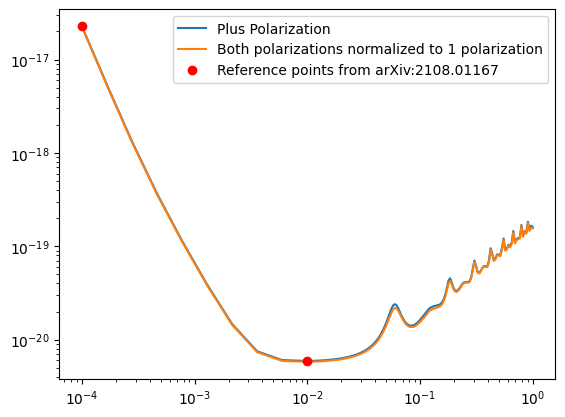

In [4]:
time_ind = 0
plt.figure()
plt.loglog(f, 1/np.mean(h_h_plus[time_ind,:,:],axis=-1)**0.5, label="Plus Polarization")
# plt.loglog(f, 1/np.mean(h_h_cross[time_ind,:,:],axis=-1)**0.5, label="LISA sensitivity Cross Polarization")
plt.loglog(f, np.sqrt(2)/np.mean(h_h[time_ind,:,:],axis=-1)**0.5, label="Both polarizations normalized to 1 polarization")
plt.plot(1e-4, (2.11e-33)**0.5 / 2, 'ro')
plt.plot(1e-2, (1.359e-40)**0.5 / 2 , 'ro', label="Reference points from arXiv:2108.01167")
plt.legend()

# Option 1: Define the instantanous requirement based on a given knowledge of the response

During science observations, the LISA observatory shall deliver a strain sensitivity of better than:
$$
S_h(t,f_0) = \Big(\frac{\langle \mathrm{SNR}^2(f_0,t,\hat k, L_{ij}(t), r_i(t),v_i(t))\rangle_{\hat k}}{2} \Big)^{-\frac{1}{2}}
$$
at any given time $t$, for the observed $L_{ij}(t), r_i(t),v_i(t)$ compliant with the LISA orbits. 

This requirement can be verified in real orbits given a best estimate coming from MOC of $L_{ij}(t), r_i(t),v_i(t)$, so as long as $L_{ij}(t), r_i(t),v_i(t)$ are compliant with the requirements then we can define this. The downside is that one should verify it across the possible evolutions of $L_{ij}(t), r_i(t),v_i(t)$. This is why we try to study in the following a way around it.

In [5]:
time_array = np.arange(0, 365, 3) * 86400

# Nominal orbit quantities
# ---------------------------------------------------------------------------
ltts      = orbits.compute_ltt(t=time_array)
positions = orbits.compute_position(t=time_array)
velocities = orbits.compute_velocity(t=time_array)
print(f"Nominal ltts shape: {ltts.shape}  |  positions shape: {positions.shape}  |  velocities shape: {velocities.shape}")

# ---------------------------------------------------------------------------
# HEALPix sky grid
# ---------------------------------------------------------------------------
nside        = 8
npix         = hp.nside2npix(nside)
thetas, phis = hp.pix2ang(nside, np.arange(npix))
betas, lambs = np.pi / 2 - thetas, phis

# ---------------------------------------------------------------------------
# Nominal strain-to-TDI matrix
# ---------------------------------------------------------------------------
print("Computing nominal strain2x …")
strain2x_nominal = compute_strain2x(f, betas, lambs, ltts, positions, velocities=velocities)
print(f"strain2x_nominal shape: {strain2x_nominal.shape}")
cov_AET = compute_covariance(f, ltts)[:,:,np.newaxis,:,:] # added an axis for sky pixels
inv_cov_AET = np.linalg.inv(cov_AET)
print(f"cov_AET shape: {cov_AET.shape}")
strain2AET = compute_strain2x(f, betas, lambs, ltts, positions, velocities=velocities)

# sum over polarizations
h_h = 4 * np.einsum("ijklm,ijklr,ijkrm->ijk",np.conj(strain2AET), inv_cov_AET, strain2AET).real
# do not sky average
sensitivity = np.sqrt(2)/h_h**0.5
print(f"h_h shape: {h_h.shape}")
print(f"sensitivity shape: {sensitivity.shape}")


Nominal ltts shape: (122, 6)  |  positions shape: (122, 3, 3)  |  velocities shape: (122, 3, 3)
Computing nominal strain2x …
strain2x_nominal shape: (122, 149, 768, 3, 2)
cov_AET shape: (122, 149, 1, 3, 3)
h_h shape: (122, 149, 768)
sensitivity shape: (122, 149, 768)


## Option 1: New requirement plot

In [7]:
print(h_h.shape, "time, frequency, sky pixels")
new_sensitivity = np.sqrt(2)/np.mean(h_h,axis=-1)**0.5
print(new_sensitivity.shape, "time, frequency")

(122, 149, 768) time, frequency, sky pixels
(122, 149) time, frequency


<>:5: SyntaxWarning: invalid escape sequence '\l'
<>:5: SyntaxWarning: invalid escape sequence '\l'
/var/folders/78/stbtx34d7vj939lq8bmh39wrx379gb/T/ipykernel_69686/3669568484.py:5: SyntaxWarning: invalid escape sequence '\l'
  plt.colorbar(label='$\log_{10}(S_h/Hz^{-1/2}$)')


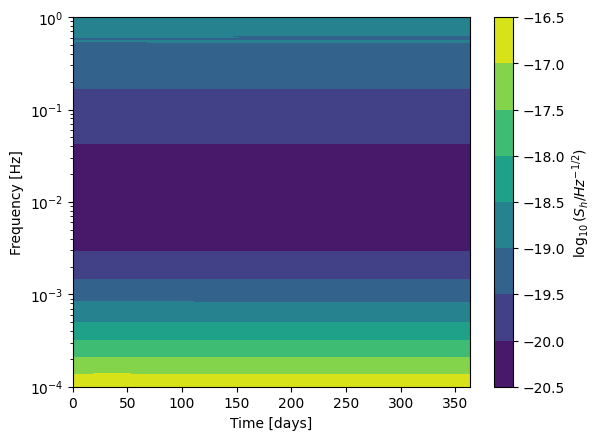

In [10]:
Timescale_response = np.abs(strain2AET / np.gradient(strain2AET, time_array, axis=0))
plt.figure()
plt.contourf(time_array / 86400, f, np.log10(new_sensitivity.T))
plt.yscale('log')
plt.colorbar(label='$\log_{10}(S_h/Hz^{-1/2}$)')
plt.xlabel('Time [days]')
plt.ylabel('Frequency [Hz]')
plt.show()

## Validity of the response approximation

<>:5: SyntaxWarning: invalid escape sequence '\l'
<>:5: SyntaxWarning: invalid escape sequence '\l'
/var/folders/78/stbtx34d7vj939lq8bmh39wrx379gb/T/ipykernel_53664/2212316987.py:5: SyntaxWarning: invalid escape sequence '\l'
  plt.colorbar(label='$\log_{10}$(Timescale/s)')


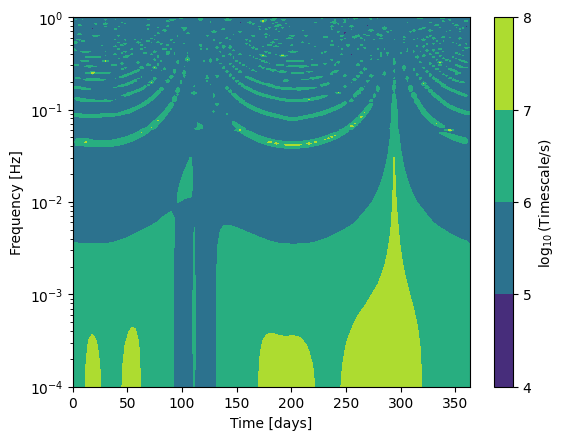

In [33]:
Timescale_response = np.abs(strain2AET / np.gradient(strain2AET, time_array, axis=0))
plt.figure()
plt.contourf(time_array / 86400, f, np.log10(Timescale_response[:, :, 0, 0, 0].T), levels=[4, 5, 6, 7, 8])
plt.yscale('log')
plt.colorbar(label='$\log_{10}$(Timescale/s)')
plt.xlabel('Time [days]')
plt.ylabel('Frequency [Hz]')
plt.show()

## Exploring across sky, time and frequency

<Figure size 640x480 with 0 Axes>

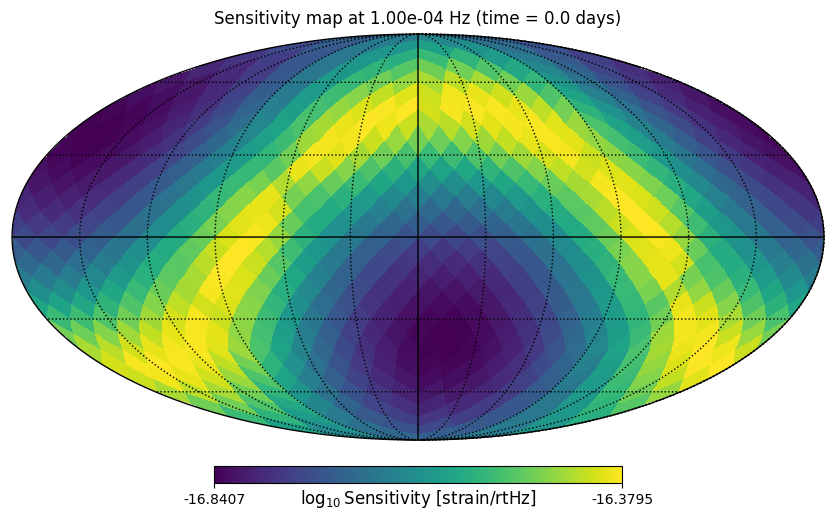

<Figure size 640x480 with 0 Axes>

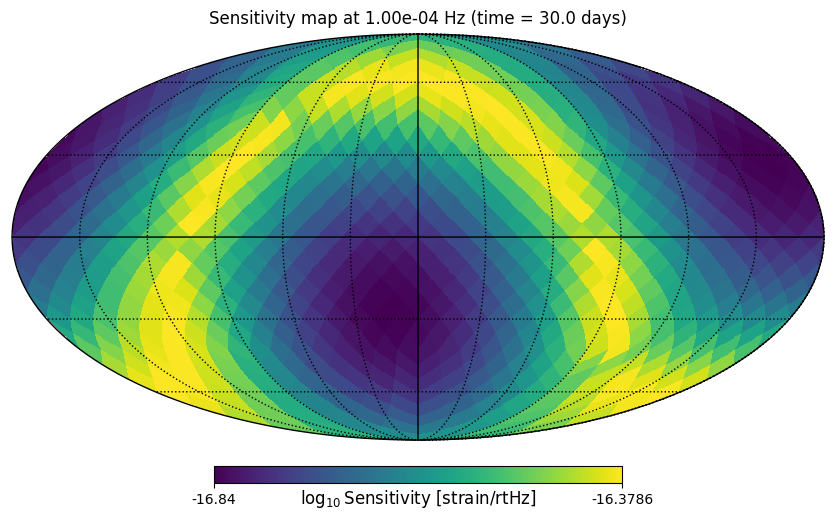

In [11]:
f_chosen = 1e-4
freq_ind = np.argmin(np.abs(f - f_chosen))
fig = plt.figure()
hp.mollview(
    np.log10(sensitivity[0,freq_ind,:]),
    title=f"Sensitivity map at {f[freq_ind]:.2e} Hz (time = {time_array[0]/86400:.1f} days)",
    unit=r"$\log_{10}$Sensitivity [strain/rtHz]",
)
hp.graticule()
plt.show()

f_chosen = 1e-4
freq_ind = np.argmin(np.abs(f - f_chosen))
fig = plt.figure()
hp.mollview(
    np.log10(sensitivity[10,freq_ind,:]),
    title=f"Sensitivity map at {f[freq_ind]:.2e} Hz (time = {time_array[10]/86400:.1f} days)",
    unit=r"$\log_{10}$Sensitivity [strain/rtHz]",
)
hp.graticule()
plt.show()


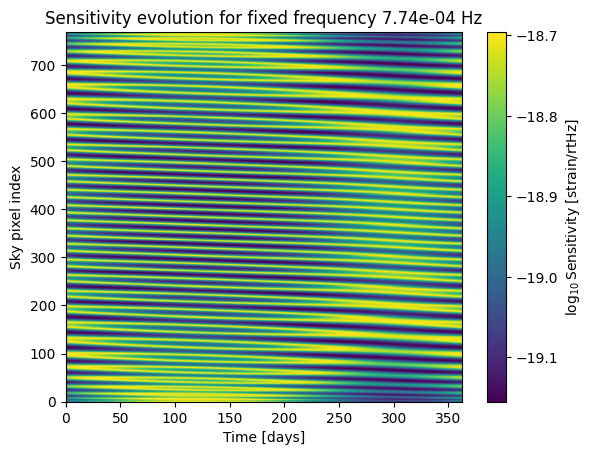

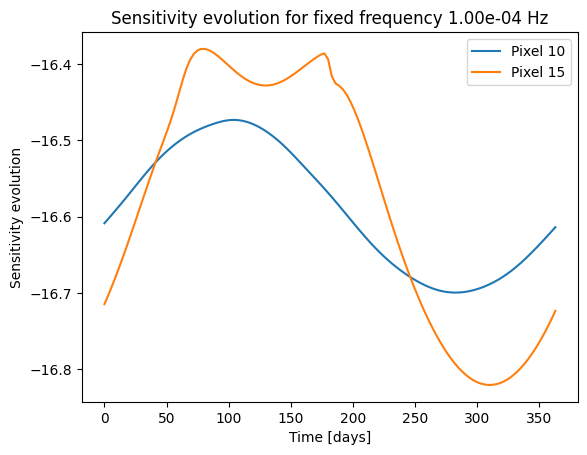

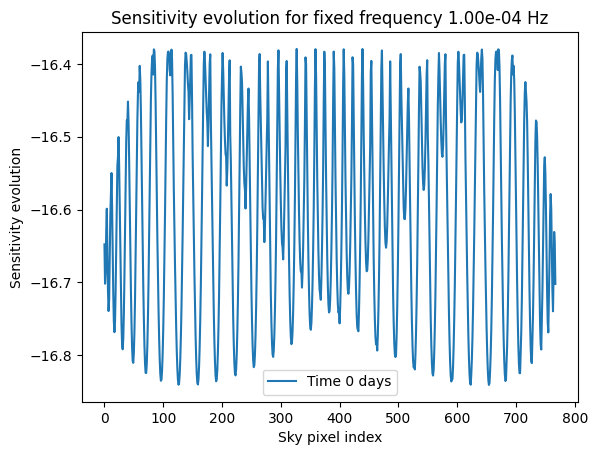

In [12]:
f_chosen = 1e-3
freq_ind = np.argmin(np.abs(f - f_chosen))
plt.figure()
plt.imshow(np.log10(sensitivity[:,freq_ind,:]).T, aspect='auto',  extent=[time_array[0]/86400, time_array[-1]/86400, 0, npix])
plt.xlabel("Time [days]")
plt.ylabel("Sky pixel index")
plt.title(f"Sensitivity evolution for fixed frequency {f[freq_ind]:.2e} Hz")
plt.colorbar(label=r"$\log_{10}$Sensitivity [strain/rtHz]")
plt.show()

f_chosen = 1e-4
freq_ind = np.argmin(np.abs(f - f_chosen))
plt.figure()
plt.plot(time_array/86400, np.log10(sensitivity[:,freq_ind,10]), label="Pixel 10")
plt.plot(time_array/86400, np.log10(sensitivity[:,freq_ind,15]), label="Pixel 15")
plt.xlabel("Time [days]")
plt.ylabel("Sensitivity evolution")
plt.title(f"Sensitivity evolution for fixed frequency {f[freq_ind]:.2e} Hz")
plt.legend()
plt.show()

plt.figure()
plt.plot(np.arange(npix), np.log10(sensitivity[0,freq_ind,:]), label="Time 0 days")
plt.xlabel("Sky pixel index")
plt.ylabel("Sensitivity evolution")
plt.title(f"Sensitivity evolution for fixed frequency {f[freq_ind]:.2e} Hz")
plt.legend()
plt.show()

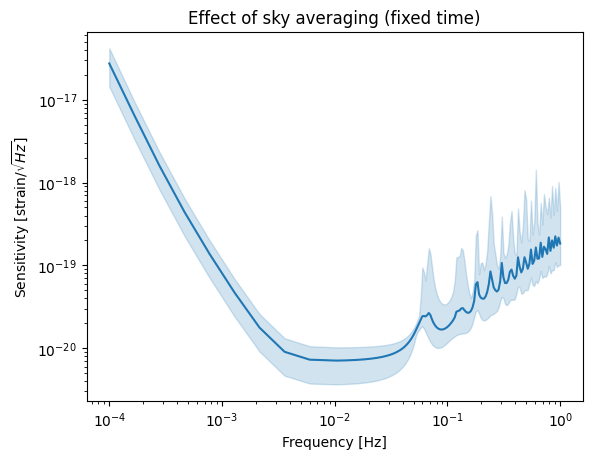

In [13]:
time_ind = 10
plt.figure()
plt.title('Effect of sky averaging (fixed time)')
upp_sky = np.max(sensitivity[time_ind,:,:],axis=-1)
low_sky = np.min(sensitivity[time_ind,:,:],axis=-1)
plt.fill_between(f, low_sky, upp_sky, color='C0', alpha=0.2, label="Range of sensitivity across sky pixels")
mean_sensitivity_sky = np.mean(sensitivity[time_ind,:,:]**2,axis=-1)**0.5
plt.loglog(f, mean_sensitivity_sky, color='C0', label="Mean sensitivity across sky pixels")
plt.xlabel("Frequency [Hz]")
plt.ylabel(r"Sensitivity [strain/$\sqrt{Hz}$]")
plt.show()

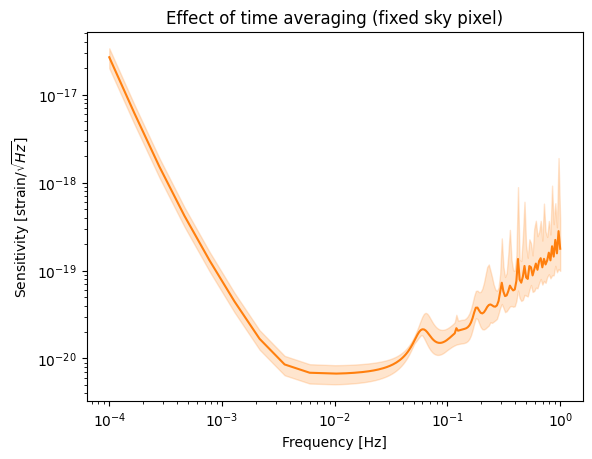

In [14]:
sky_pixel = 10
plt.figure()
plt.title('Effect of time averaging (fixed sky pixel)')
upp_time = np.max(sensitivity[:,:,sky_pixel],axis=0)
low_time = np.min(sensitivity[:,:,sky_pixel],axis=0)
plt.fill_between(f, low_time, upp_time, color='C1', alpha=0.2, label="Range of sensitivity across time")
mean_sensitivity_time = np.mean(sensitivity[:,:,sky_pixel]**2,axis=0)**0.5
plt.loglog(f, mean_sensitivity_time, color='C1', label="Mean sensitivity across time")
plt.xlabel("Frequency [Hz]")
plt.ylabel(r"Sensitivity [strain/$\sqrt{Hz}$]")
plt.show()

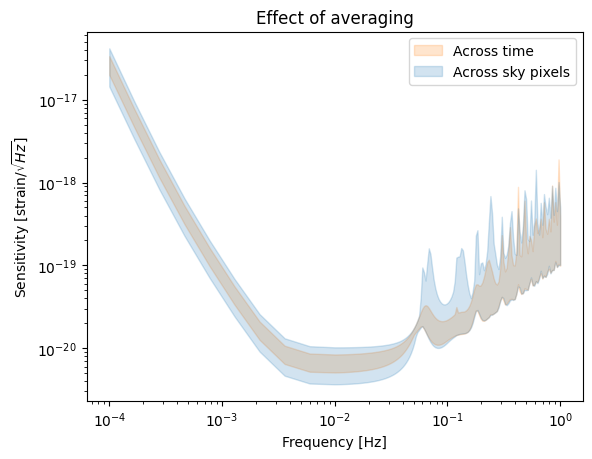

In [15]:

plt.figure()
plt.title('Effect of averaging')
plt.fill_between(f, low_time, upp_time, color='C1', alpha=0.2, label="Across time")
plt.fill_between(f, low_sky, upp_sky, color='C0', alpha=0.2, label="Across sky pixels")
plt.loglog()
plt.legend()
plt.xlabel("Frequency [Hz]")
plt.ylabel(r"Sensitivity [strain/$\sqrt{Hz}$]")
plt.show()

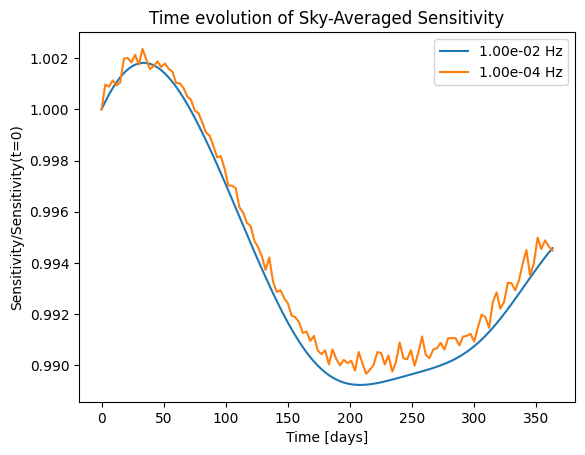

In [16]:
plt.figure()
f_chosen = 1e-2
freq_ind = np.argmin(np.abs(f - f_chosen))
temp_sens_ev = np.mean(sensitivity[:,freq_ind,:], axis=-1)
plt.plot(time_array/86400, temp_sens_ev/temp_sens_ev[0], label=f'{f[freq_ind]:.2e} Hz')
f_chosen = 1e-4
freq_ind = np.argmin(np.abs(f - f_chosen))
temp_sens_ev = np.mean(sensitivity[:,freq_ind,:], axis=-1)
plt.plot(time_array/86400, temp_sens_ev/temp_sens_ev[0], label=f'{f[freq_ind]:.2e} Hz')

plt.xlabel("Time [days]")
plt.ylabel("Sensitivity/Sensitivity(t=0)")
plt.title("Time evolution of Sky-Averaged Sensitivity")
plt.legend()
plt.show()

# What happens with different noise levels?

In [17]:
time_array = np.arange(0, 365, 7) * 86400

# Nominal orbit quantities
# ---------------------------------------------------------------------------
ltts      = orbits.compute_ltt(t=time_array)
positions = orbits.compute_position(t=time_array)
velocities = orbits.compute_velocity(t=time_array)
print(f"Nominal ltts shape: {ltts.shape}  |  positions shape: {positions.shape}  |  velocities shape: {velocities.shape}")

# ---------------------------------------------------------------------------
# HEALPix sky grid
# ---------------------------------------------------------------------------
nside        = 8 # reduced
npix         = hp.nside2npix(nside)
thetas, phis = hp.pix2ang(nside, np.arange(npix))
betas, lambs = np.pi / 2 - thetas, phis

# ---------------------------------------------------------------------------
# Nominal strain-to-TDI matrix
# ---------------------------------------------------------------------------
print("Computing nominal strain2x …")
strain2x_nominal = compute_strain2x(f, betas, lambs, ltts, positions, velocities=velocities)
strain2AET = compute_strain2x(f, betas, lambs, ltts, positions, velocities=velocities)
print(f"strain2x_nominal shape: {strain2x_nominal.shape}")

Nominal ltts shape: (53, 6)  |  positions shape: (53, 3, 3)  |  velocities shape: (53, 3, 3)
Computing nominal strain2x …
strain2x_nominal shape: (53, 149, 768, 3, 2)


1.35e-11 2.7e-15
1.5e-11 3e-15


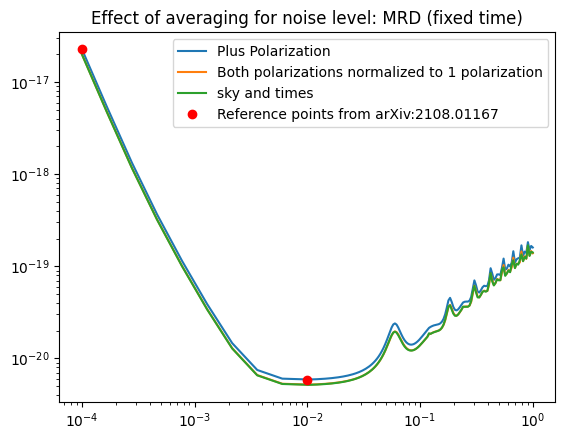

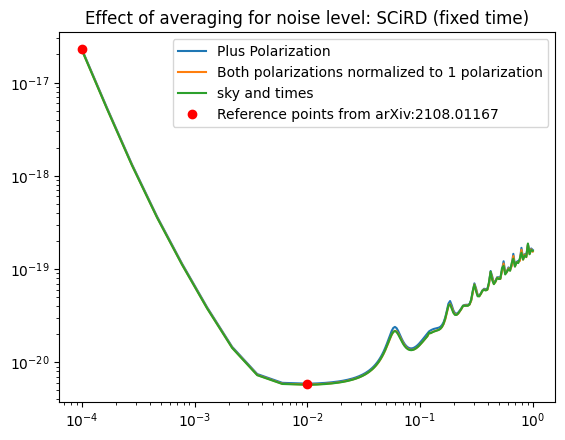

In [18]:
noise_levels = {
    "MRD": {"oms_ref": 13.5e-12, "tm_ref": 2.7e-15},
    "SCiRD": {"oms_ref": 1.5e-11, "tm_ref": 3e-15}
}
hh_dict = {}

for noise_key, noise_params in noise_levels.items():
    print(noise_levels[noise_key]["oms_ref"], noise_levels[noise_key]["tm_ref"])
    cov_ = compute_covariance(f, ltts, oms_ref=noise_levels[noise_key]["oms_ref"], tm_ref=noise_levels[noise_key]["tm_ref"])[:,:,np.newaxis,:,:] # added an axis for sky pixels
    inv_cov_ = np.linalg.inv(cov_)

    # sum over polarizations
    h_h = 4 * np.einsum("ijklm,ijklr,ijkrm->ijk",np.conj(strain2AET), inv_cov_, strain2AET).real
    # do not sky average
    # sensitivity = np.sqrt(2)/h_h**0.5
    time_ind = 0
    sensitivity = np.sqrt(2)/np.mean(h_h[time_ind],axis=-1)**0.5
    hh_dict[noise_key] = h_h

    time_ind = 0
    plt.figure()
    plt.title(f'Effect of averaging for noise level: {noise_key} (fixed time)')
    plt.loglog(f, 1/np.mean(h_h_plus[time_ind,:,:],axis=-1)**0.5, label="Plus Polarization")
    # plt.loglog(f, 1/np.mean(h_h_cross[time_ind,:,:],axis=-1)**0.5, label="LISA sensitivity Cross Polarization")
    plt.loglog(f, np.sqrt(2)/np.mean(h_h[time_ind,:,:],axis=-1)**0.5, label="Both polarizations normalized to 1 polarization")
    sensitivity_time_sky = np.sqrt(2)/np.mean(h_h,axis=(0,2))**0.5
    plt.loglog(f, sensitivity_time_sky, label="sky and times")
    plt.plot(1e-4, (2.11e-33)**0.5 / 2, 'ro')
    plt.plot(1e-2, (1.359e-40)**0.5 / 2 , 'ro', label="Reference points from arXiv:2108.01167")
    plt.legend()

In [19]:
# average across times
ltt_mean_evolution = np.mean(ltts,axis=1)

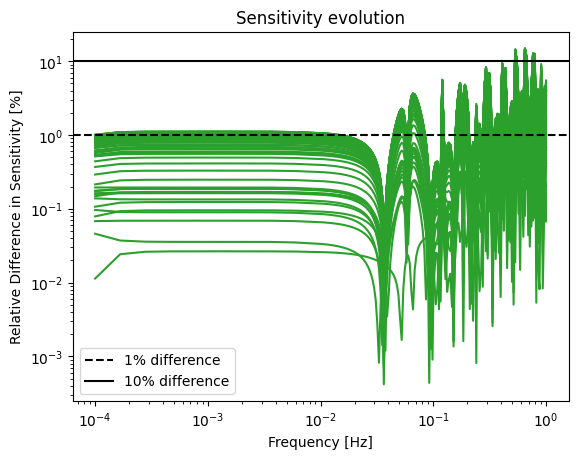

In [20]:
f_chosen = 1e-4
freq_ind = np.argmin(np.abs(f - f_chosen))
plt.figure()
sensitivity_ref = np.sqrt(2)/np.mean(hh_dict["SCiRD"][0,:], axis=1)**0.5
sensitivity_t_ev = np.sqrt(2)/np.mean(hh_dict["SCiRD"][:,:], axis=-1)**0.5
plt.loglog(f, 100*np.abs(1-sensitivity_t_ev.T/sensitivity_ref[:,None]), color='C2')
plt.axhline(1, color='k', linestyle='--', label="1% difference")
plt.axhline(10, color='k', linestyle='-', label="10% difference")
plt.xlabel("Frequency [Hz]")
plt.ylabel(r"Relative Difference in Sensitivity [%]")
plt.title("Sensitivity evolution")
plt.legend()

In [21]:
percent = 1-np.arange(-3, 3, 0.5)/100
percent = np.append(percent, 1.0)
percent = np.sort(percent)
sensitivity_dict = {}
for p in percent:
    orbits_stat = StaticConstellation.from_armlengths(2.5e9*p, 2.5e9*p, 2.5e9*p)
    time_array = [0]

    # Nominal orbit quantities
    # ---------------------------------------------------------------------------
    ltts      = orbits_stat.compute_ltt(t=time_array)
    positions = orbits_stat.compute_position(t=time_array)
    velocities = orbits_stat.compute_velocity(t=time_array)
    print(f"Nominal ltts shape: {ltts.shape}  |  positions shape: {positions.shape}  |  velocities shape: {velocities.shape}")

    # ---------------------------------------------------------------------------
    # HEALPix sky grid
    # ---------------------------------------------------------------------------
    nside        = 8 # reduced
    npix         = hp.nside2npix(nside)
    thetas, phis = hp.pix2ang(nside, np.arange(npix))
    betas, lambs = np.pi / 2 - thetas, phis

    # ---------------------------------------------------------------------------
    # Nominal strain-to-TDI matrix
    # ---------------------------------------------------------------------------
    print("Computing nominal strain2x …")
    strain2x_nominal = compute_strain2x(f, betas, lambs, ltts, positions, velocities=velocities)
    strain2AET = compute_strain2x(f, betas, lambs, ltts, positions, velocities=velocities)
    print(f"strain2x_nominal shape: {strain2x_nominal.shape}")
    
    cov_ = compute_covariance(f, ltts, oms_ref=noise_levels[noise_key]["oms_ref"], tm_ref=noise_levels[noise_key]["tm_ref"])[:,:,np.newaxis,:,:] # added an axis for sky pixels
    inv_cov_ = np.linalg.inv(cov_)

    # sum over polarizations
    h_h = 4 * np.einsum("ijklm,ijklr,ijkrm->ijk",np.conj(strain2AET), inv_cov_, strain2AET).real
    # do not sky average
    # sensitivity = np.sqrt(2)/h_h**0.5
    time_ind = 0
    sensitivity = np.sqrt(2)/np.mean(h_h[time_ind],axis=-1)**0.5
    sensitivity_dict[p] = sensitivity
    print(h_h.shape)


Nominal ltts shape: (1, 6)  |  positions shape: (1, 3, 3)  |  velocities shape: (1, 3, 3)
Computing nominal strain2x …
strain2x_nominal shape: (1, 149, 768, 3, 2)
(1, 149, 768)
Nominal ltts shape: (1, 6)  |  positions shape: (1, 3, 3)  |  velocities shape: (1, 3, 3)
Computing nominal strain2x …
strain2x_nominal shape: (1, 149, 768, 3, 2)
(1, 149, 768)
Nominal ltts shape: (1, 6)  |  positions shape: (1, 3, 3)  |  velocities shape: (1, 3, 3)
Computing nominal strain2x …
strain2x_nominal shape: (1, 149, 768, 3, 2)
(1, 149, 768)
Nominal ltts shape: (1, 6)  |  positions shape: (1, 3, 3)  |  velocities shape: (1, 3, 3)
Computing nominal strain2x …
strain2x_nominal shape: (1, 149, 768, 3, 2)
(1, 149, 768)
Nominal ltts shape: (1, 6)  |  positions shape: (1, 3, 3)  |  velocities shape: (1, 3, 3)
Computing nominal strain2x …
strain2x_nominal shape: (1, 149, 768, 3, 2)
(1, 149, 768)
Nominal ltts shape: (1, 6)  |  positions shape: (1, 3, 3)  |  velocities shape: (1, 3, 3)
Computing nominal strain2

Text(0.5, 1.0, 'Sensitivity variation with arm length')

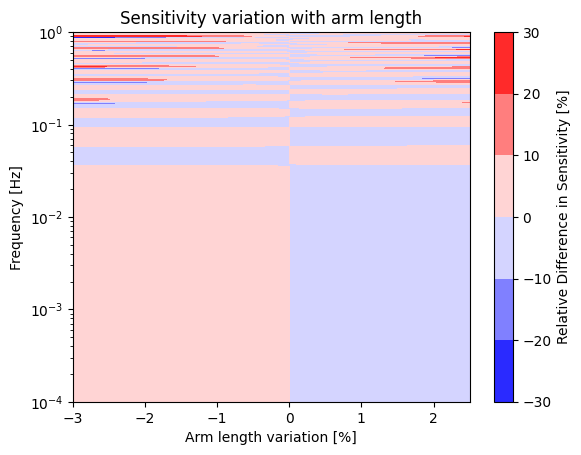

In [22]:
array_relative_sensitivity_percent = np.asarray([100*(1-sensitivity_dict[p]/sensitivity_dict[1.0]) for p in percent])
plt.figure()
# plt.imshow(array_relative_sensitivity_percent.T, extent=[(1-percent[0])*100, (1-percent[-1])*100, f[0], f[-1]], aspect='auto')
CS = plt.contourf((1-percent)*100, f, array_relative_sensitivity_percent.T, 
                  levels=[-30, -20, -10, 0, 10, 20, 30], cmap='bwr', )
plt.colorbar(CS, label="Relative Difference in Sensitivity [%]")

plt.semilogy()

plt.xlabel("Arm length variation [%]")
plt.ylabel("Frequency [Hz]")
plt.title("Sensitivity variation with arm length")


## Option 2:  Define the requirement based on a grid of armlengths and ignore S/C positions and velocities



During science observations, the LISA observatory shall deliver a strain sensitivity of better than:
$$
S_h(f_0,L) = \Big(\frac{\langle \mathrm{SNR}^2(f_0, \hat k, L, r_i,v_i)\rangle_{\hat k}}{2} \Big)^{-\frac{1}{2}}
$$
for a grid armlength $L$ assuming a fixed $r_i, v_i$. 

Again now we are setting the requirement adding another dimensions but assuming only armlengths variations within a certain range. This is suboptimal given that in reality the constallation degrees of freedom are more complicated than an overall armlength $L$.

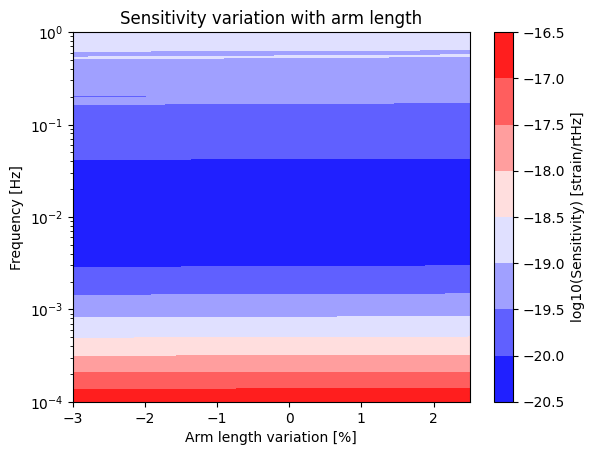

In [23]:
sensitivity_grid = np.asarray([sensitivity_dict[p] for p in percent])
plt.figure()
# plt.imshow(array_relative_sensitivity_percent.T, extent=[(1-percent[0])*100, (1-percent[-1])*100, f[0], f[-1]], aspect='auto')
CS = plt.contourf((1-percent)*100, f, np.log10(sensitivity_grid.T), cmap='bwr', )
plt.colorbar(CS, label="log10(Sensitivity) [strain/rtHz]")

plt.semilogy()

plt.xlabel("Arm length variation [%]")
plt.ylabel("Frequency [Hz]")
plt.title("Sensitivity variation with arm length")
plt.show()